# Worked Examples in Generative AI: Prompt Engineering & Evaluation

This notebook shows two worked examples using a pretrained Large Language Model (LLM):

- **Dataset A:** Geography QA (capitals)
- **Dataset B:** Arithmetic word problems

For each dataset, we:
- Define prompts (our “generative model interface”)
- Call the LLM
- Evaluate with simple metrics
- Compare behavior across datasets


In [1]:
import os, re, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

# Optional: OpenAI client
try:
    from openai import OpenAI
    client = OpenAI()
    OPENAI_AVAILABLE = True
except Exception:
    OPENAI_AVAILABLE = False

def call_model(prompt: str, model: str = "gpt-4.1-mini", max_output_tokens: int = 64) -> str:
    if OPENAI_AVAILABLE:
        try:
            r = client.responses.create(
                model=model,
                input=prompt,
                max_output_tokens=max_output_tokens,
            )
            return r.output[0].content[0].text.strip()
        except Exception as e:
            print("Error:", e)
            return ""
    else:
        # Mock so notebook still runs
        return "MOCK_OUTPUT"


In [2]:
def normalize_text(text: str) -> str:
    if text is None:
        return ""
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s\.\-]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def extract_final_answer(text: str) -> str:
    if not text:
        return ""
    m = re.search(r"final answer\s*:\s*(.*)", text, re.IGNORECASE | re.DOTALL)
    return m.group(1).strip() if m else text.strip()

def exact_match(pred: str, gold: str) -> float:
    return float(normalize_text(pred) == normalize_text(gold))

def f1_tokens(pred: str, gold: str) -> float:
    p = normalize_text(pred).split()
    g = normalize_text(gold).split()
    if not p or not g:
        return 0.0
    common = set(p) & set(g)
    num = sum(min(p.count(t), g.count(t)) for t in common)
    if num == 0:
        return 0.0
    precision = num / len(p)
    recall = num / len(g)
    return 2 * precision * recall / (precision + recall)


In [3]:
# ---- Dataset A: Geography QA ----
data_a = [
    {"id": 1, "q": "What is the capital of France?", "a": "Paris"},
    {"id": 2, "q": "What is the capital of Japan?", "a": "Tokyo"},
    {"id": 3, "q": "What is the capital of India?", "a": "New Delhi"},
    {"id": 4, "q": "What is the capital of Canada?", "a": "Ottawa"},
    {"id": 5, "q": "What is the capital of Brazil?", "a": "Brasília"},
]
df_a = pd.DataFrame(data_a)

PROMPTS_A = {
    "baseline": """Answer the following question in one or two words.

Question: {q}
Answer:""",
    "cot": """You are a geography tutor. Solve step by step and then give the capital.

Question: {q}

Final answer:""",
}

results_a = []
for tmpl_name, tmpl in PROMPTS_A.items():
    for _, row in df_a.iterrows():
        prompt = tmpl.format(q=row["q"])
        out = call_model(prompt)
        ans = extract_final_answer(out)
        results_a.append({
            "dataset": "A",
            "prompt": tmpl_name,
            "id": row["id"],
            "gold": row["a"],
            "pred": ans,
            "em": exact_match(ans, row["a"]),
            "f1": f1_tokens(ans, row["a"]),
            "length": len(out.split()) if out else 0,
        })
        if OPENAI_AVAILABLE:
            time.sleep(0.2)

res_a_df = pd.DataFrame(results_a)
res_a_df.head()


,dataset,prompt,id,gold,pred,em,f1,length
0,A,baseline,1,Paris,MOCK_OUTPUT,0.0,0.0,1
1,A,baseline,2,Tokyo,MOCK_OUTPUT,0.0,0.0,1
2,A,baseline,3,New Delhi,MOCK_OUTPUT,0.0,0.0,1
3,A,baseline,4,Ottawa,MOCK_OUTPUT,0.0,0.0,1
4,A,baseline,5,Brasília,MOCK_OUTPUT,0.0,0.0,1


In [4]:
# ---- Dataset B: Arithmetic Word Problems ----
data_b = [
    {"id": 1, "q": "If you have 3 apples and buy 4 more, how many apples do you have in total?", "a": "7"},
    {"id": 2, "q": "You read 5 pages on Monday and 7 on Tuesday. How many pages in total?", "a": "12"},
    {"id": 3, "q": "A box has 10 chocolates. You eat 3. How many are left?", "a": "7"},
    {"id": 4, "q": "There are 4 birds on a tree and 6 more join. How many birds now?", "a": "10"},
    {"id": 5, "q": "You had 18 marbles and lost 9. How many marbles remain?", "a": "9"},
]
df_b = pd.DataFrame(data_b)

PROMPTS_B = {
    "baseline": """Answer the following math question with just the final number.

Question: {q}
Answer:""",
    "cot": """You are a math tutor. Solve step by step and then give only the final number.

Question: {q}

Final answer:""",
}

results_b = []
for tmpl_name, tmpl in PROMPTS_B.items():
    for _, row in df_b.iterrows():
        prompt = tmpl.format(q=row["q"])
        out = call_model(prompt)
        ans = extract_final_answer(out)
        results_b.append({
            "dataset": "B",
            "prompt": tmpl_name,
            "id": row["id"],
            "gold": row["a"],
            "pred": ans,
            "em": exact_match(ans, row["a"]),
            "f1": f1_tokens(ans, row["a"]),
            "length": len(out.split()) if out else 0,
        })
        if OPENAI_AVAILABLE:
            time.sleep(0.2)

res_b_df = pd.DataFrame(results_b)
res_b_df.head()


,dataset,prompt,id,gold,pred,em,f1,length
0,B,baseline,1,7,MOCK_OUTPUT,0.0,0.0,1
1,B,baseline,2,12,MOCK_OUTPUT,0.0,0.0,1
2,B,baseline,3,7,MOCK_OUTPUT,0.0,0.0,1
3,B,baseline,4,10,MOCK_OUTPUT,0.0,0.0,1
4,B,baseline,5,9,MOCK_OUTPUT,0.0,0.0,1


In [5]:
# Combine and aggregate
all_res = pd.concat([res_a_df, res_b_df], ignore_index=True)

agg = (
    all_res
    .groupby(["dataset", "prompt"])
    .agg(
        avg_em=("em", "mean"),
        avg_f1=("f1", "mean"),
        avg_len=("length", "mean"),
    )
    .reset_index()
)
agg


,dataset,prompt,avg_em,avg_f1,avg_len
0,A,baseline,0.0,0.0,1.0
1,A,cot,0.0,0.0,1.0
2,B,baseline,0.0,0.0,1.0
3,B,cot,0.0,0.0,1.0


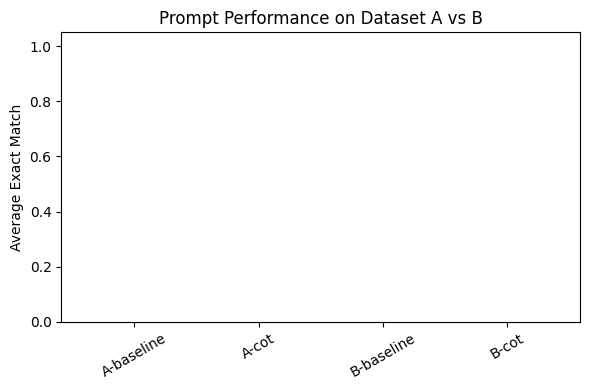

In [6]:
# Bar plot: Exact Match by dataset & prompt
fig, ax = plt.subplots(figsize=(6, 4))

labels = []
vals = []
for _, r in agg.iterrows():
    labels.append(f"{r['dataset']}-{r['prompt']}")
    vals.append(r["avg_em"])

ax.bar(labels, vals)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Average Exact Match")
ax.set_title("Prompt Performance on Dataset A vs B")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 5. Discussion

- **Dataset A (Geography)**  
  Short factual answers. Performance mostly depends on the model’s stored world knowledge.
  Chain-of-thought may not help much beyond formatting.

- **Dataset B (Arithmetic)**  
  Requires reasoning. Chain-of-thought prompting can help the model reason step by step
  and reduce mistakes, especially on slightly harder problems.

Dataset type (knowledge vs reasoning) changes **how useful** prompt techniques are.

---

## 6. Extensions & Exercises

1. **New prompt template (JSON output) for Dataset A**  
   - Ask the model to answer as: `{"capital": "<city>"}`  
   - Evaluate exact match on the `"capital"` field.

2. **Constraint metric for Dataset B**  
   - Define a function that returns 1 if the final answer is a pure integer
     (e.g., `"12"`), else 0.  
   - Compare constraint satisfaction across prompts.

3. **Harder arithmetic problems**  
   - Add new questions with multiplication/division.  
   - Re-run and see if chain-of-thought gains become larger.

---

## 7. Conclusion

We used a pretrained LLM as a generative model and showed:

- How **prompt design** changes behavior on two different datasets.
- How to use **simple metrics** (Exact Match, F1) to compare prompts.
- How dataset characteristics (fact vs reasoning) affect model performance.

---

## 8. References

- OpenAI Prompt Engineering docs  
- Vaswani et al., *Attention Is All You Need* (2017)  
- Brown et al., *Language Models are Few-Shot Learners* (2020)


# 7. License

MIT License

Copyright (c) 2025 Chinmay Sawant

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.